In [2]:
# Reset the built-in str back to normal
import builtins
str = builtins.str

# Now run the line
chars = sorted(list(set(''.join(words))))

NameError: name 'words' is not defined

In [1]:
words = open('names.txt','r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [2]:
len(words)

32033

In [2]:
import torch

In [3]:
N = torch.zeros((27,27), dtype=torch.int32)

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."]= 0

In [5]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2]+=1

In [6]:
itos={i:s for s,i in stoi.items()}

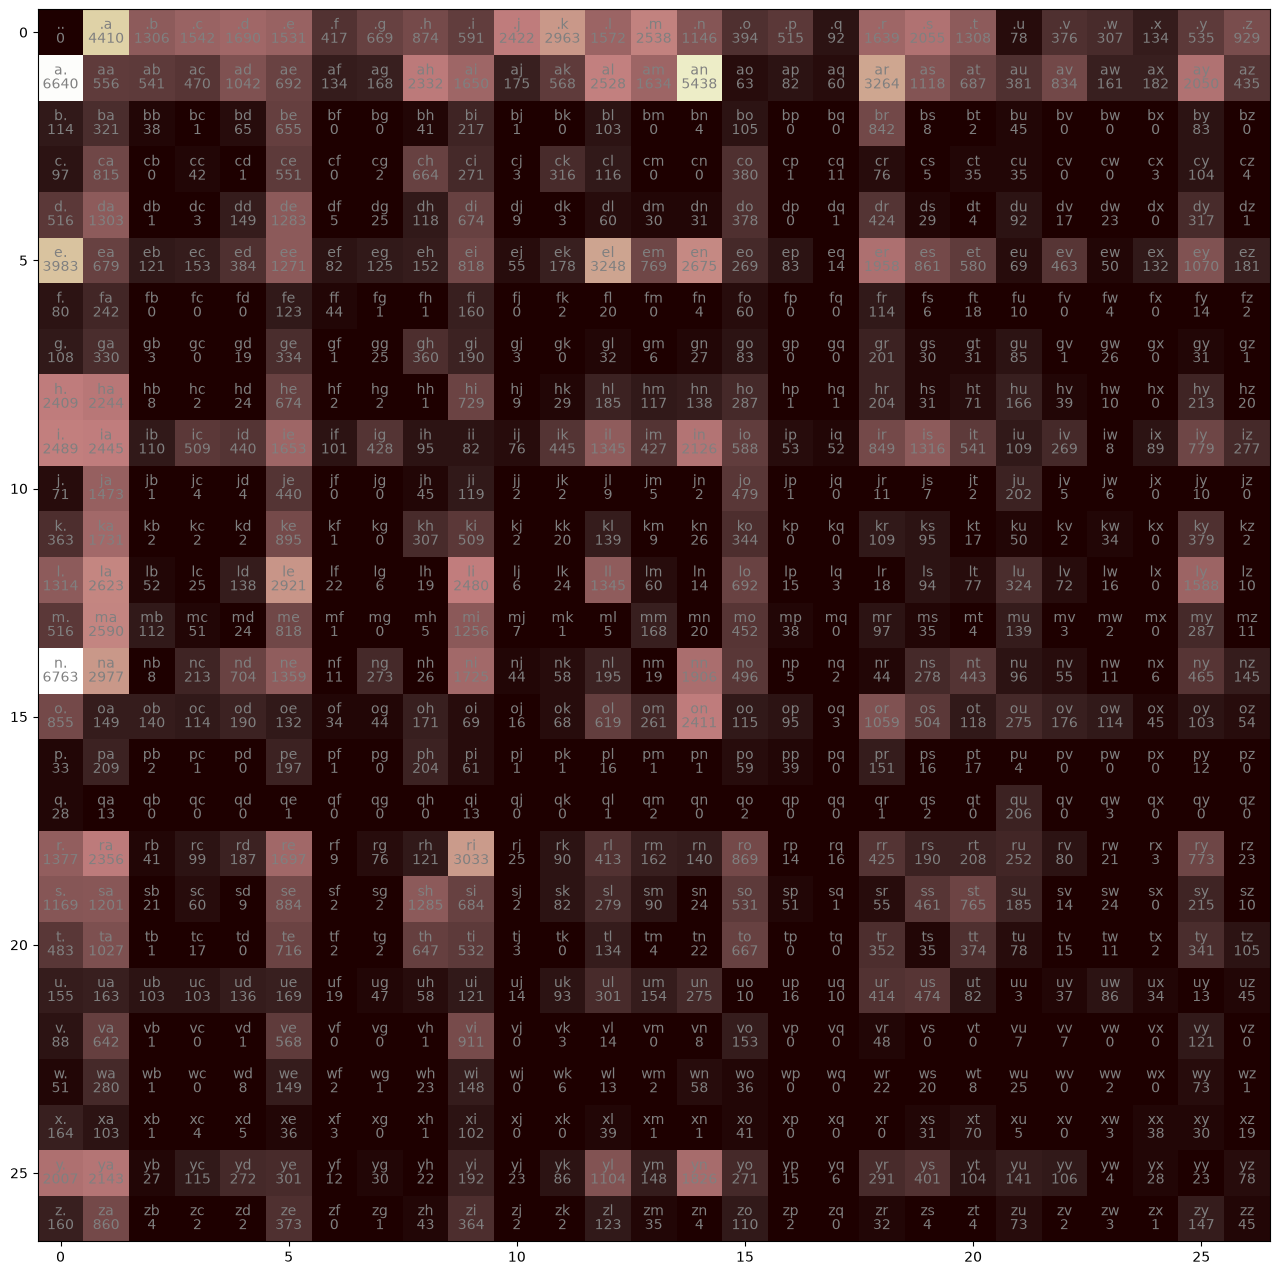

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N, cmap="pink")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j,i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j,i, N[i, j].item(), ha="center", va="top", color="gray")

In [8]:
P = (N+1).float()
P /= P.sum(1,keepdim=True)

P[13,1]

tensor(0.3885)

In [68]:
g = torch.Generator().manual_seed(2147483647)
for i in range(15):
    out = []
    ix = 0
    while True:
        p=P[ix]

        ix=torch.multinomial(p,num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.


In [10]:
log_likelihood=0.0
n=0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob=P[ix1,ix2]
        logprob=torch.log(prob)
        log_likelihood+=logprob
        n+=1

nll=-log_likelihood
print(f'{nll/n}')

2.4543561935424805


In [ ]:
xs=[]
ys=[]
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)  #tensor of inputs
ys = torch.tensor(ys)  #tensor of desired outputs

In [ ]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float() #turnign those inputs into an array of 27

In [189]:
g=torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True) #ranodmly initializing 27 neurons that receive 27 inputs

In [190]:
#FORWARD PASS WITH INPUTS
logits = xenc @ W #matrix multiplications of the inputs and weights to get a 5x27 array of logits (raw predictions) for each of the 5 characters in the word
#softmax
counts= logits.exp() #exponentiating the logits to get positive values
probs = counts/counts.sum(1, keepdim=True) #normalizing the counts to get probabilities for each character in the word
#LOSS FUNCTION(PART OF FORWARD PASS)
loss=-probs[torch.arange(5), ys].log().mean()

In [176]:
#BACKWARD PASS
W.grad=None
loss.backward()

In [177]:
W.data += -50*W.grad

In [193]:
loss.item()

1.2366235256195068

In [ ]:
xs=[]
ys=[]
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)  #tensor of inputs
ys = torch.tensor(ys)  #tensor of desired outputs
num = xs.nelement() #number of elements in the tensor

In [2008]:
for i in range(10):
    xenc = F.one_hot(xs, num_classes=27).float() #turnign those inputs into an array of 27
    #FORWARD PASS WITH INPUTS
    logits = xenc @ W #matrix multiplications of the inputs and weights to get a 5x27 array of logits (raw predictions) for each of the 5 characters in the word
    #softmax
    counts= logits.exp() #exponentiating the logits to get positive values
    probs = counts/counts.sum(1, keepdim=True) #normalizing the counts to get probabilities for each character in the word
    #LOSS FUNCTION(PART OF FORWARD PASS)
    loss=-probs[torch.arange(num), ys].log().mean()

    #BACKWARD PASS
    W.grad=None
    loss.backward()

    #UPDATE WEIGHTS
    W.data += -50*W.grad

    print(loss.item())


2.4551591873168945
2.455157995223999
2.4551568031311035
2.455155611038208
2.4551546573638916
2.455153703689575
2.4551522731781006
2.455151319503784
2.4551503658294678
2.455148696899414


In [2004]:
W.shape

torch.Size([27, 27])

In [ ]:
#it has the 22k inputs (F.one_hot formatted), a lot of the inputs might be the same and theyre coming from different bigrams but they all contribute towards hte loss

tensor([ 5, 13, 13,  1,  0])